In [1]:
from datetime import datetime

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import curve_fit
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

In [2]:
%load_ext blackcellmagic

In [3]:
intervals = (
    pd.read_csv(
        "data/rowing.csv",
        skiprows=3,
        usecols=[2, 3] + list(range(9, 16)),
        parse_dates=["Date"],
    )
    .dropna()
    .drop(columns=["Cal/hr"])  # Highly correlated to Watt
)

intervals = intervals[intervals["Date"] != pd.to_datetime("2024-05-06")]
intervals = intervals[intervals["Date"] != pd.to_datetime("2024-08-27")]
intervals = intervals[
    (intervals["Date"] != pd.to_datetime("2024-12-20"))
    | (intervals["Time of Day"] < "12:00")
]
intervals = intervals[
    (intervals["Date"] != pd.to_datetime("2025-01-02"))
    | (intervals["Time of Day"] > "15:00")
]
intervals = intervals[
    (intervals["Date"] != pd.to_datetime("2025-01-05"))
    | (intervals["Time of Day"] < "15:00")
]

intervals = intervals.rename(
    columns={col: col[:-2] for col in intervals.columns if col.endswith(".1")}
)
intervals = intervals.loc[intervals["Time"].str[3:] == "00.0"]
intervals = intervals.loc[intervals["Heart Rate"] > 0]
intervals["Interval"] = (intervals["Time"].str[:2].astype(float) / 5).astype(int)
intervals["Day"] = intervals["Date"].apply(lambda date: date.toordinal())
intervals["Efficiency"] = intervals["Meters"] / (intervals["Heart Rate"] * 5)

intervals.head(10)

,Date,Time of Day,Time,Meters,SPM,Heart Rate,/500m,Watt,Interval,Day,Efficiency
1,2025-04-11,11:54,05:00.0,1142.0,27.0,154.0,02:11.3,154,1,739352,1.483117
2,2025-04-11,11:54,10:00.0,1082.0,29.0,155.0,02:18.6,131,2,739352,1.396129
3,2025-04-11,11:54,15:00.0,1059.0,29.0,154.0,02:21.6,123,3,739352,1.375325
4,2025-04-11,11:54,20:00.0,1048.0,29.0,155.0,02:23.1,119,4,739352,1.352258
5,2025-04-11,11:54,25:00.0,1029.0,29.0,156.0,02:25.7,113,5,739352,1.319231
6,2025-04-11,11:54,30:00.0,1020.0,29.0,157.0,02:27.0,110,6,739352,1.299363
9,2025-04-09,14:02,05:00.0,1061.0,26.0,133.0,02:21.3,124,1,739350,1.595489
10,2025-04-09,14:02,10:00.0,1025.0,27.0,132.0,02:26.3,112,2,739350,1.553030
11,2025-04-09,14:02,15:00.0,1008.0,27.0,131.0,02:28.8,106,3,739350,1.538931
12,2025-04-09,14:02,20:00.0,1003.0,26.0,136.0,02:29.5,105,4,739350,1.475000


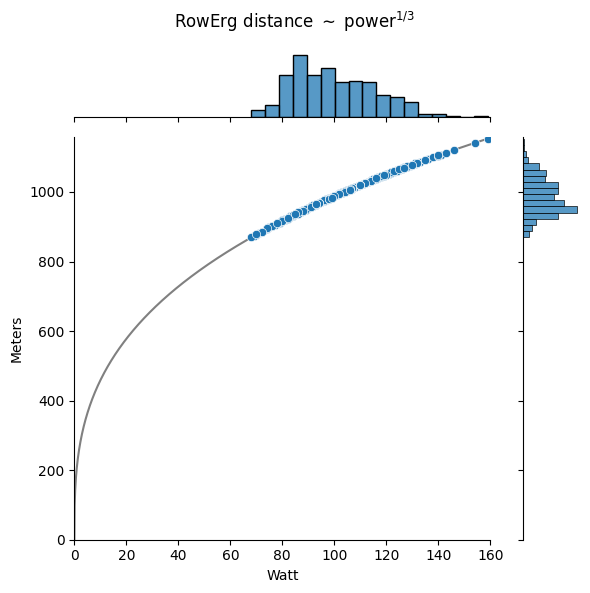

In [4]:
def distance(power, a):
    return a * power ** (1/3)


sns.jointplot(intervals, x="Watt", y="Meters", xlim=[0, 160], ylim=[0, 1159])
plt.suptitle(r"RowErg distance $\sim$ power$^{1/3}$")
popt, _ = curve_fit(distance, intervals["Watt"], intervals["Meters"])
power = np.arange(0, 170, 0.1)
plt.plot(power, distance(power, popt), color="0.5", zorder=0)
plt.tight_layout()
plt.savefig("rowing_watt-vs-meters.png")
plt.show()

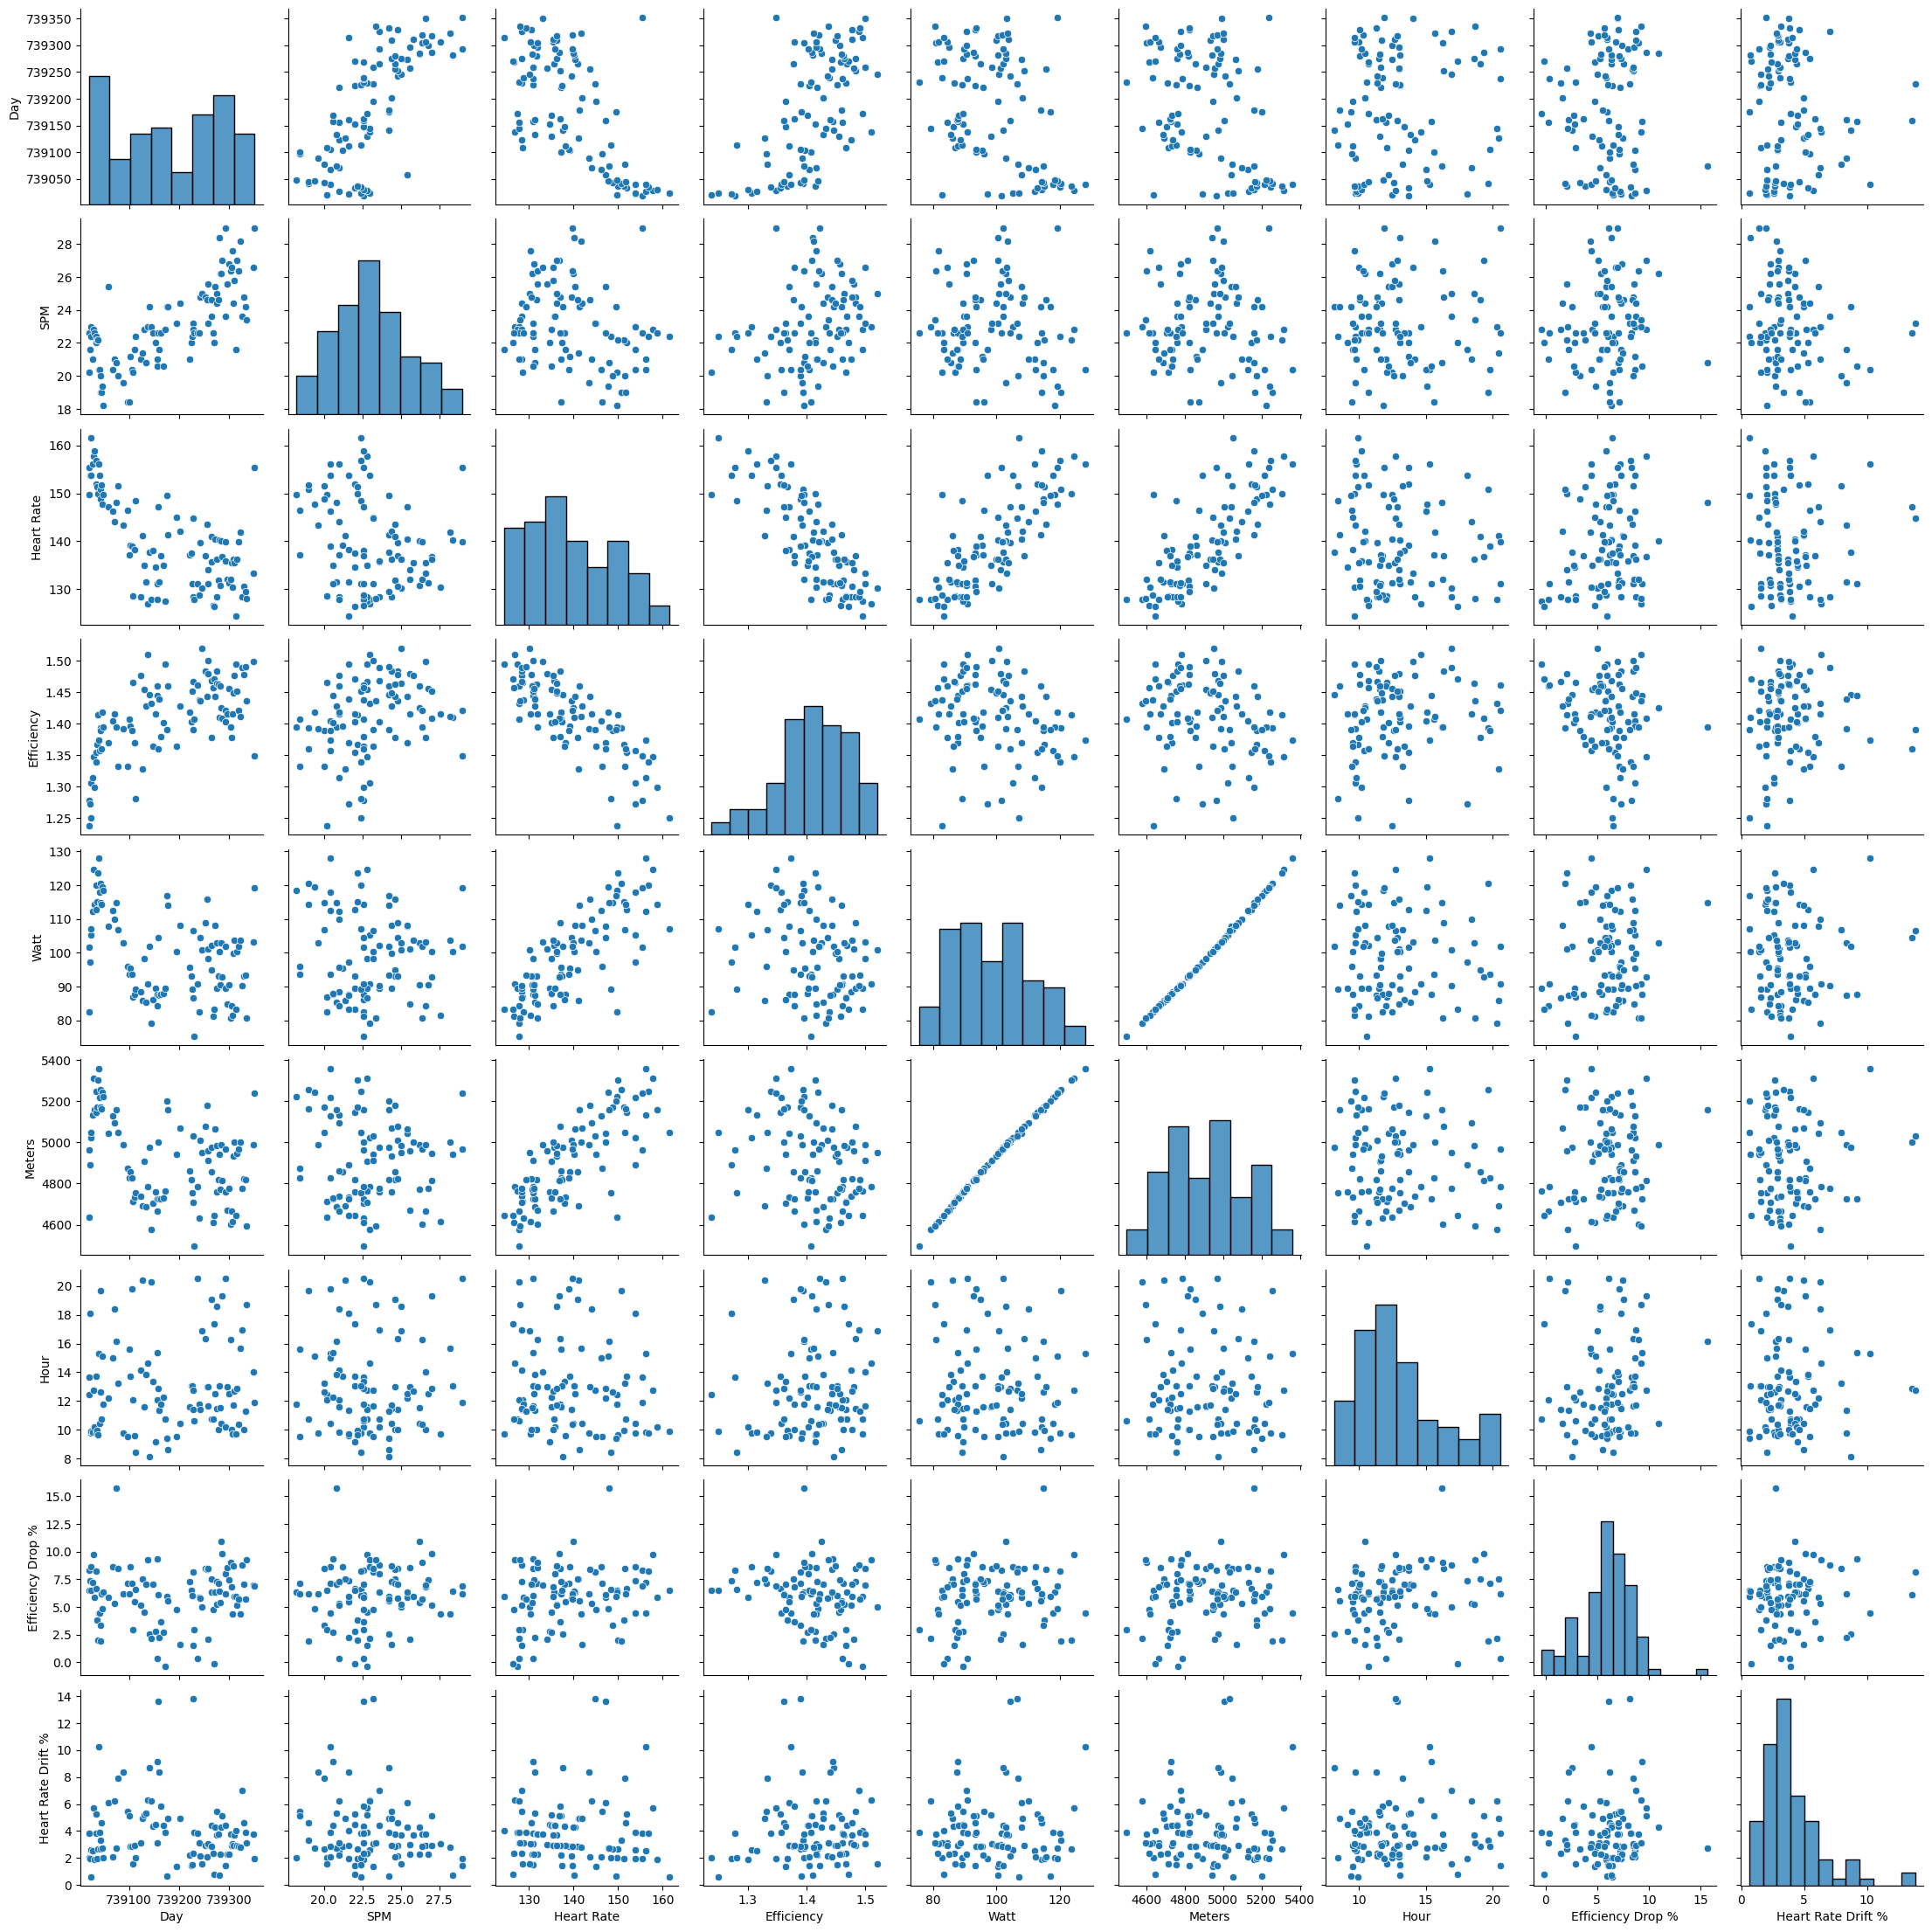

In [5]:
def analyze(session):
    """
    It usually takes me about five minutes to get into a rhythm and I usually
    row for at least half an hour. So I throw the rest away and only analyse
    the intervals two to five of each session.
    """
    if len(session) < 6:
        return

    session = session.iloc[1:6]

    result = session[["SPM", "Heart Rate", "Efficiency", "Watt"]].mean()
    result["Meters"] = session["Meters"].sum()
    result["Hour"] = pd.to_timedelta(
        session.iloc[0]["Time of Day"] + ":00"
    ) / pd.to_timedelta("1h")
    result["Efficiency Drop %"] = 100 * (
        (session["Efficiency"].iloc[0] - session["Efficiency"].iloc[-1])
        / session["Efficiency"].iloc[0]
    )
    result["Heart Rate Drift %"] = 100 * (
        (session["Heart Rate"].max() - session["Heart Rate"].min())
        / session["Heart Rate"].mean()
    )
    return result


sessions = intervals.groupby("Day").apply(analyze, include_groups=False)
sns.pairplot(sessions.reset_index())
plt.savefig("rowing-data.png")
plt.show()

In [6]:
conconi = pd.read_csv("data/rowing_conconi.csv", parse_dates=["Timestamp"])
conconi["Day"] = conconi["Timestamp"].apply(lambda date: date.toordinal())
conconi.head()

,Timestamp,Watt,Heart Rate,Machine,Step,Day
0,2024-05-06 12:54:00,40,145,RowErg,4,739012
1,2024-05-06 12:56:00,60,153,RowErg,4,739012
2,2024-05-06 12:57:00,80,160,RowErg,4,739012
3,2024-05-06 13:00:00,100,167,RowErg,4,739012
4,2024-05-06 13:02:00,120,174,RowErg,4,739012


C:\Users\qiv\AppData\Local\Temp\ipykernel_21596\3166453451.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


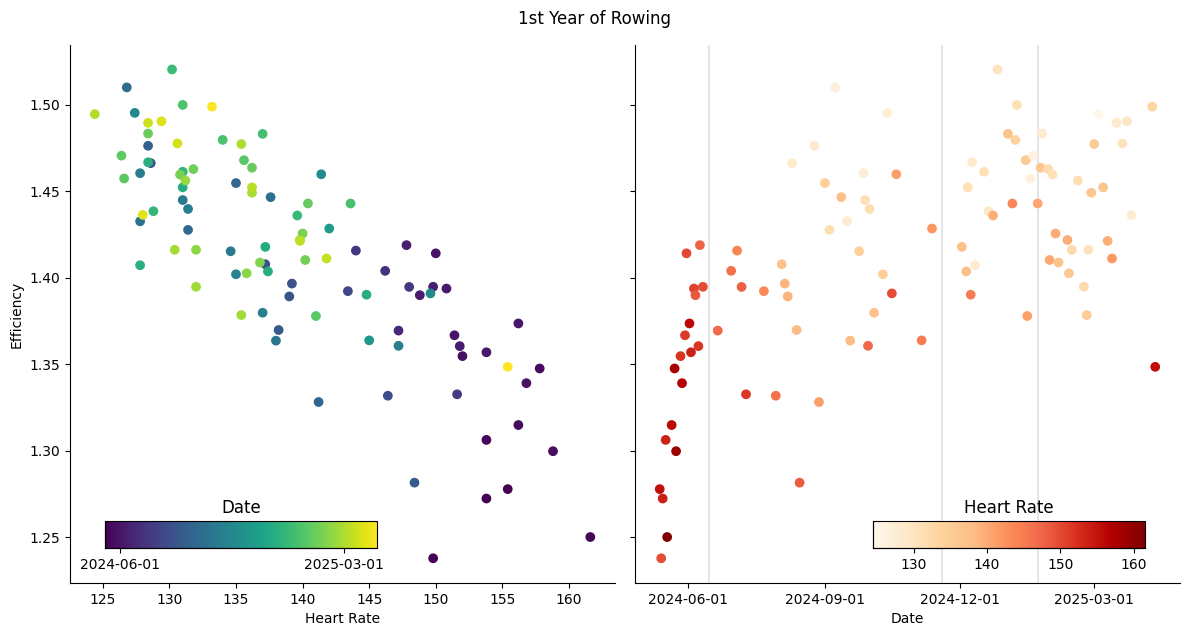

In [7]:
fig, axs = plt.subplots(ncols=2, sharey=True, figsize=(12, 6.44))
fig.suptitle("1st Year of Rowing")
plt.tight_layout()

norm = plt.Normalize(sessions.index.min(), sessions.index.max())
axs[0].scatter(
    sessions["Heart Rate"],
    sessions["Efficiency"],
    c=sessions.index,
    norm=norm,
    cmap="viridis",
)
smap = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
axins1 = inset_axes(axs[0], width="50%", height="5%", loc="lower left", borderpad=2.5)
axins1.xaxis.set_ticks_position("bottom")
axins1.set_title("Date")
fig.colorbar(smap, cax=axins1, orientation="horizontal")
dates = [
    "2024-06-01",
    "2025-03-01",
]
axins1.set_xticks([datetime.fromisoformat(date).toordinal() for date in dates], dates)

axs[0].set_xlabel("Heart Rate")
axs[0].set_ylabel("Efficiency")

norm = plt.Normalize(sessions["Heart Rate"].min(), sessions["Heart Rate"].max())
axs[1].scatter(
    sessions.index,
    sessions["Efficiency"],
    c=sessions["Heart Rate"],
    norm=norm,
    cmap="OrRd",
)

smap = plt.cm.ScalarMappable(cmap="OrRd", norm=norm)
axins2 = inset_axes(axs[1], width="50%", height="5%", loc="lower right", borderpad=2.5)
axins2.set_title("Heart Rate")
axins2.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(smap, cax=axins2, orientation="horizontal", ticks=[130, 140, 150, 160])

axs[1].set_xlabel("Date")
dates = [
    "2024-06-01",
    "2024-09-01",
    "2024-12-01",
    "2025-03-01",
]
axs[1].set_xticks([datetime.fromisoformat(date).toordinal() for date in dates], dates)

for label, date in {
    "Knee pain": "2024-06-15",
    "Sick": "2024-11-19",
    "Sick II": "2025-01-22",
}.items():
    date = datetime.fromisoformat(date).toordinal()
    axs[1].annotate(label, (date + 3, 6.3), c="0.5")
    axs[1].axvline(date, c="0.9", zorder=0)

sns.despine()
plt.tight_layout()
plt.savefig("rowing.png")
plt.show()

In [8]:
sessions.head()

,SPM,Heart Rate,Efficiency,Watt,Meters,Hour,Efficiency Drop %,Heart Rate Drift %
Day,,,,,,,,
739019,22.6,155.4,1.277747,101.6,4962.0,13.683333,8.315258,3.861004
739020,20.2,149.8,1.237743,82.6,4635.0,12.466667,6.534574,2.002670
739021,21.6,153.8,1.272298,97.2,4892.0,18.100000,7.345739,1.950585
739023,23.0,153.8,1.306211,105.2,5021.0,9.766667,8.636716,2.600780
739024,22.4,161.6,1.250027,107.2,5050.0,9.916667,6.482364,0.618812


In [9]:
def f(x, E_0, a, b, t):
    day, hr = x[:, 0] - x[:, 0].min(), x[:, 1]
    return (E_0 - a * hr) * (1 - b * np.exp(-day / t))

In [10]:
curve_fit(f, sessions.reset_index()[["Day", "Heart Rate"]].values, sessions["Efficiency"])

(array([2.01688904e+00, 4.30578286e-03, 8.26030123e-02, 5.37278405e+00]),
 array([[ 3.99111488e-03,  2.89923871e-05, -1.18015764e-04,
         -9.01567988e-02],
        [ 2.89923871e-05,  2.11261161e-07, -8.86908531e-07,
         -6.72491929e-04],
        [-1.18015764e-04, -8.86908531e-07,  3.27684548e-04,
         -1.98497399e-02],
        [-9.01567988e-02, -6.72491929e-04, -1.98497399e-02,
          7.49235252e+00]]))

In [11]:
def f(x, E_0, b, t):
    day, hr = x[:, 0] - x[:, 0].min(), x[:, 1]
    return E_0 * (1 - b * np.exp(-day / t))

In [12]:
curve_fit(
    f,
    sessions[sessions.index > 73903].reset_index()[["Day", "Heart Rate"]].values,
    sessions[sessions.index > 73903]["Efficiency"],
)

C:\Users\qiv\AppData\Local\Temp\ipykernel_21596\1184569687.py:3: RuntimeWarning: overflow encountered in exp
  return E_0 * (1 - b * np.exp(-day / t))


(array([ 1.44034407,  0.09744114, 53.03257448]),
 array([[ 4.79312470e-05,  9.91761718e-06,  6.66900704e-02],
        [ 9.91761718e-06,  1.16066121e-04, -6.39727075e-02],
        [ 6.66900704e-02, -6.39727075e-02,  2.25815974e+02]]))

In [13]:
# xdata = sessions.reset_index()[["Day", "Heart Rate"]].values
# xdata[:, 1] = np.mean(xdata[:, 1])
# plt.scatter(sessions.index, sessions["Efficiency"])
# plt.plot(
#     sessions.index,
#     f(xdata, 2.03522556, 0.00444466, 0.00365812, 0.02629418),
# )
# plt.vlines([739030], 1.2, 1.6)

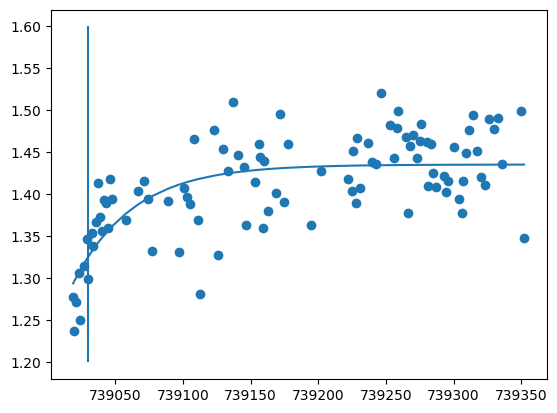

In [14]:
xdata = sessions.reset_index()[["Day", "Heart Rate"]].values
xdata[:, 1] = np.mean(xdata[:, 1])
plt.scatter(sessions.index, sessions["Efficiency"])
plt.plot(
    sessions.index,
    f(xdata, 1.43562249,  0.09857152, 43.95938732),
)
plt.vlines([739030], 1.2, 1.6)

In [15]:
def f(x, E_0, a):
    day, hr = x[:, 0] - x[:, 0].min(), x[:, 1]
    return E_0 - a * hr

In [16]:
curve_fit(
    f,
    sessions.reset_index()[["Day", "Heart Rate"]].values,
    sessions["Efficiency"],
)

(array([2.12667   , 0.00512684]),
 array([[2.96323555e-03, 2.11325326e-05],
        [2.11325326e-05, 1.51383644e-07]]))

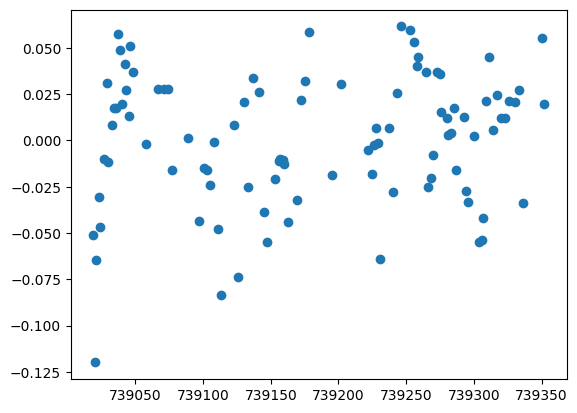

In [17]:
xdata = sessions.reset_index()[["Day", "Heart Rate"]].values

plt.scatter(sessions.index, sessions["Efficiency"] - f(xdata, 2.13129403, 0.00516427))
# plt.plot(
#     sessions.index,
#     sessions["Efficiency"] - f(xdata, 2.13129403, 0.00516427),
# )
# plt.vlines([739030], 1.2, 1.6)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [19]:
sessions["Time"] = sessions.index - sessions.index.min()

In [20]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=50)
    beta = pm.HalfNormal("beta", sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = -alpha + beta * sessions["Heart Rate"]

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

In [21]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

CPU times: total: 8.2 s
Wall time: 4.21 s


In [22]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.HalfNormal("beta", sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = -alpha + beta * sessions["Heart Rate"]

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

In [23]:
%%time
with model:
    idata2 = pm.sample(nuts_sampler="numpyro")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

CPU times: total: 4.27 s
Wall time: 2.33 s


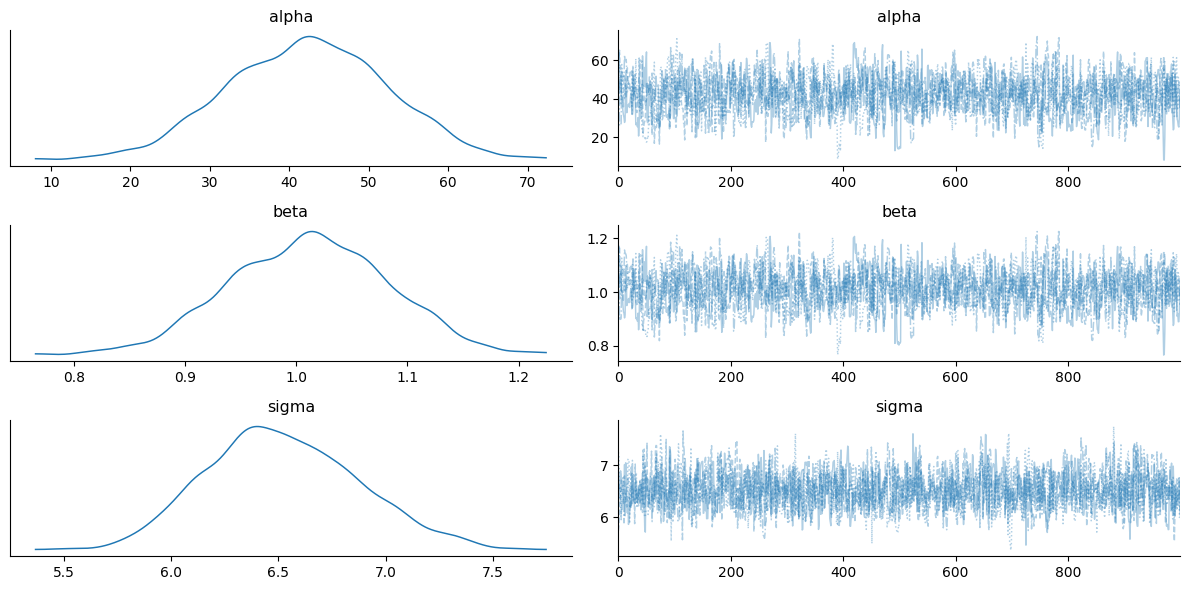

In [24]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

In [25]:
def f(hr, a, b):
    return a + b * hr

In [26]:
curve_fit(f, sessions["Heart Rate"], sessions["Watt"])

(array([-44.6306823 ,   1.02857853]),
 array([[ 1.40151071e+02, -9.99497704e-01],
        [-9.99497704e-01,  7.15993725e-03]]))

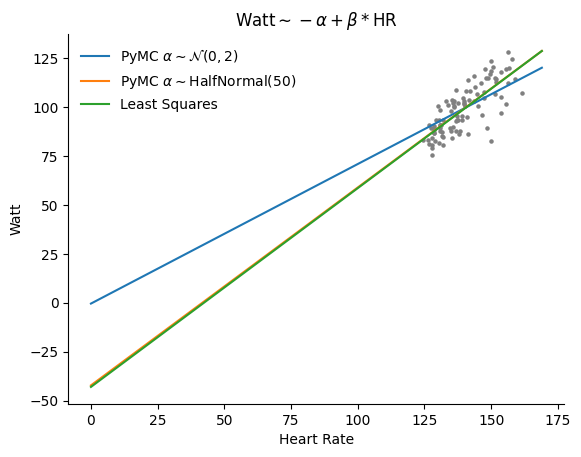

In [27]:
plt.scatter(sessions["Heart Rate"], sessions["Watt"], color="0.5", s=5)

plt.title(r"$\text{Watt} \sim -\alpha + \beta * \text{HR}$")

hr = np.arange(0, 170, 1)
plt.plot(hr, -idata2.posterior["alpha"].mean().values + idata2.posterior["beta"].mean().values * hr, label=r"PyMC $\alpha \sim \mathcal{N}(0, 2)$")
plt.plot(hr, -idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * hr, label=r"PyMC $\alpha \sim \text{HalfNormal}(50)$")
plt.plot(hr, f(hr, -43.0136827 ,   1.01583838), label="Least Squares")
plt.legend(frameon=False)
plt.xlabel("Heart Rate")
plt.ylabel("Watt")
sns.despine()
plt.show()

In [28]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=60)
    # beta = pm.HalfNormal("beta", sigma=5)
    beta = pm.Normal("beta", mu=3, sigma=0.0125)
    sigma = pm.HalfNormal("sigma", sigma=5)
    tau = pm.HalfNormal("tau", sigma=50)
    # delta = pm.Normal("delta", mu=0, sigma=10)
    gamma = pm.HalfNormal("gamma", sigma=60)

    # Expected value of outcome
    mu = -alpha + beta * sessions["Heart Rate"].values - gamma * np.exp(- sessions["Time"].values / tau)

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

In [29]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

CPU times: total: 5.52 s
Wall time: 2.75 s


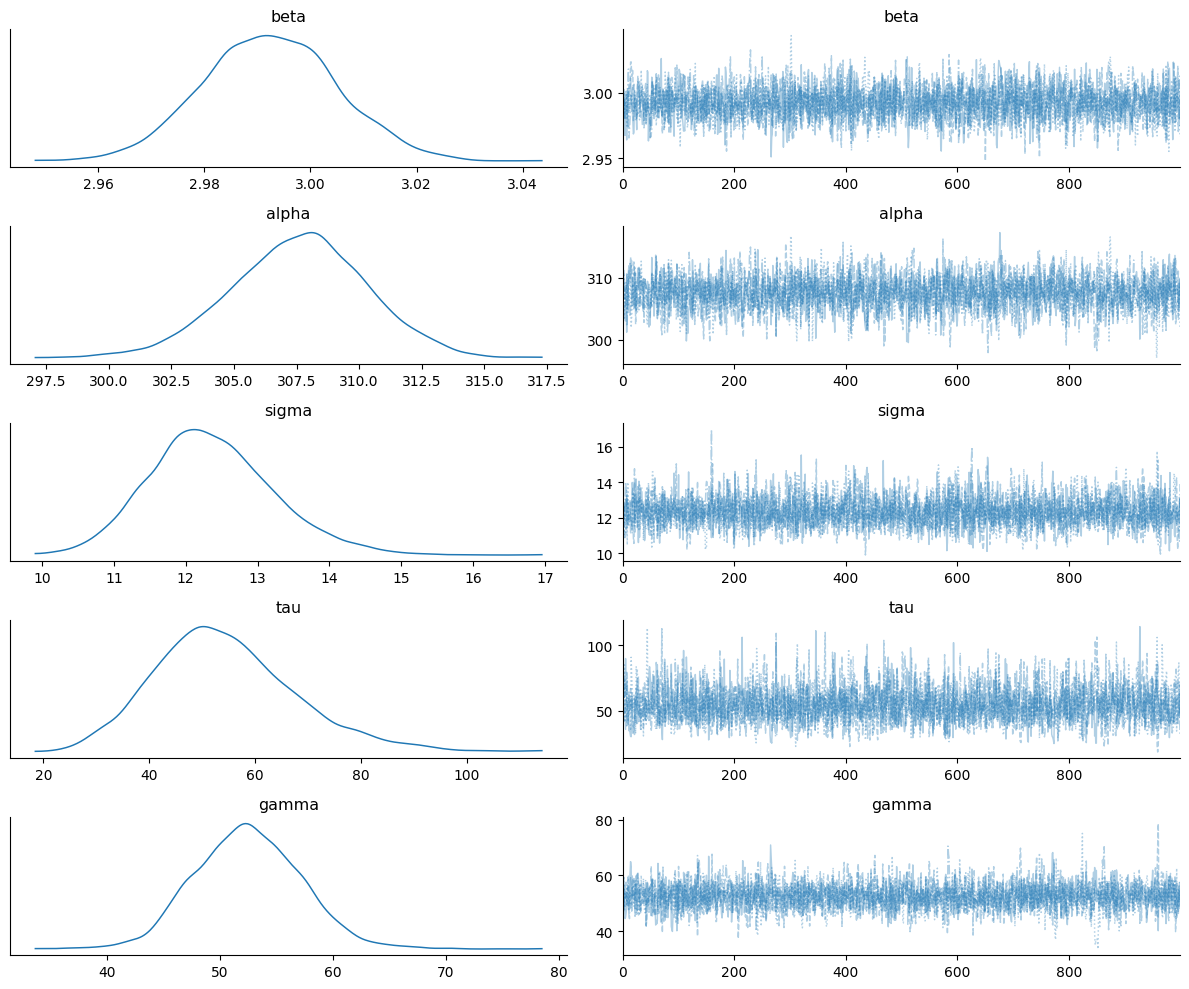

In [30]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\qiv\AppData\Local\Temp\ipykernel_21596\3526220063.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


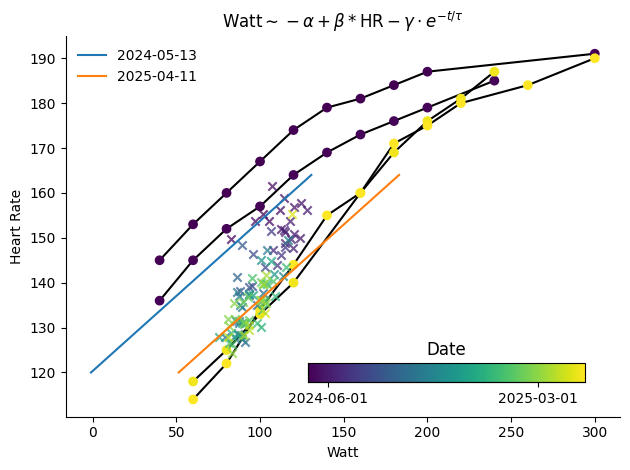

In [31]:
plt.title(
    r"$\text{Watt} \sim -\alpha + \beta * \text{HR} - \gamma \cdot e^{-t / \tau}$"
)

norm = plt.Normalize(
    min(intervals["Day"].min(), conconi["Day"].min()),
    max(intervals["Day"].max(), conconi["Day"].max()),
)

for _, data in conconi.groupby("Day"):
    plt.plot(data["Watt"], data["Heart Rate"], color="0", zorder=-1)
    plt.scatter(data["Watt"], data["Heart Rate"], c=data["Day"], norm=norm)


for day, session in sessions.iterrows():
    plt.scatter(
        session["Watt"], session["Heart Rate"], c=day, norm=norm, marker="x", alpha=0.75
    )

plt.xlabel("Watt")
plt.ylabel("Heart Rate")


hr = np.arange(120, 165, 1)

for day, time in [
    (sessions.index.min(), sessions["Time"].min()),
    (sessions.index.max(), sessions["Time"].max()),
]:
    plt.plot(
        -idata.posterior["alpha"].mean().values
        + idata.posterior["beta"].mean().values * hr
        - idata.posterior["gamma"].mean().values
        * np.exp(-time / idata.posterior["tau"].mean().values),
        hr,
        label=datetime.fromordinal(day).date(),
    )
plt.legend(frameon=False)

smap = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
axins1 = inset_axes(
    plt.gca(), width="50%", height="5%", loc="lower right", borderpad=2.5
)
axins1.xaxis.set_ticks_position("bottom")
axins1.set_title("Date")
fig.colorbar(smap, cax=axins1, orientation="horizontal")
dates = [
    "2024-06-01",
    "2025-03-01",
]
axins1.set_xticks([datetime.fromisoformat(date).toordinal() for date in dates], dates)

sns.despine()
plt.tight_layout()
plt.savefig("rowing_hr-vs-watt.png")
plt.show()

In [32]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=2, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta * sessions["Heart Rate"]

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Efficiency"])

In [33]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

CPU times: total: 20.3 s
Wall time: 6.35 s


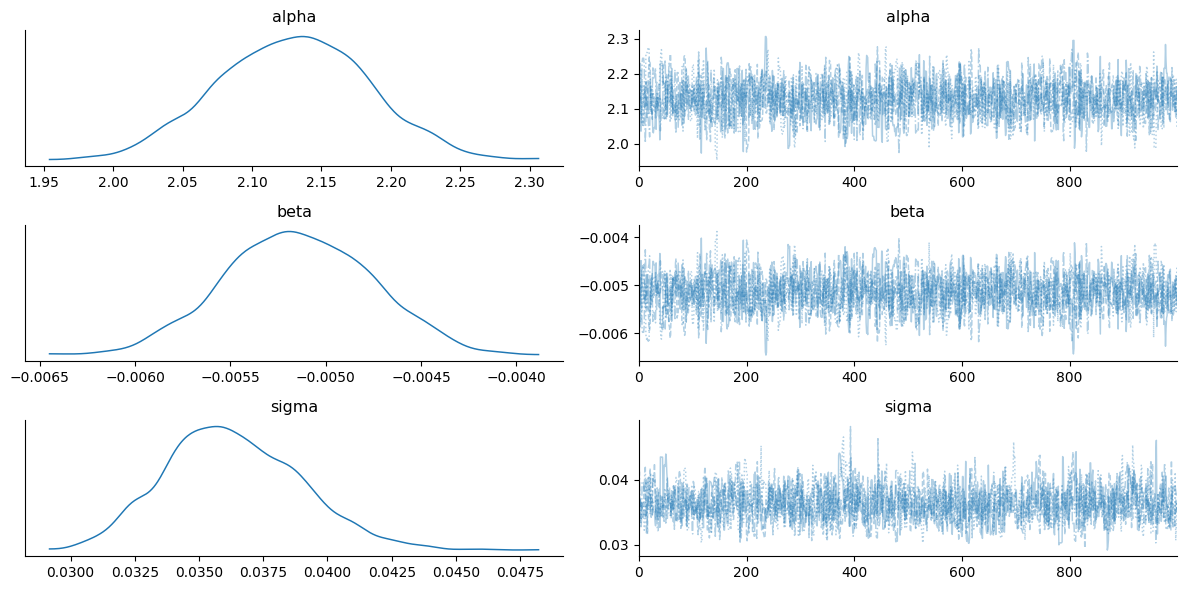

In [34]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

In [35]:
with pm.Model() as model:
    # Priors for unknown model parameters
    eta = pm.HalfNormal("eta", sigma=1)
    beta = pm.HalfNormal("beta", sigma=1)
    tau = pm.Normal("tau", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    # E_0 * (1 - b * np.exp(-day / t))
    # (E_0 - a * hr) * (1 - b * np.exp(-day / t))
    mu = eta * (1 - np.exp(tau - sessions["Time"].values / beta))

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Efficiency"])

In [36]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

CPU times: total: 4.58 s
Wall time: 2.24 s


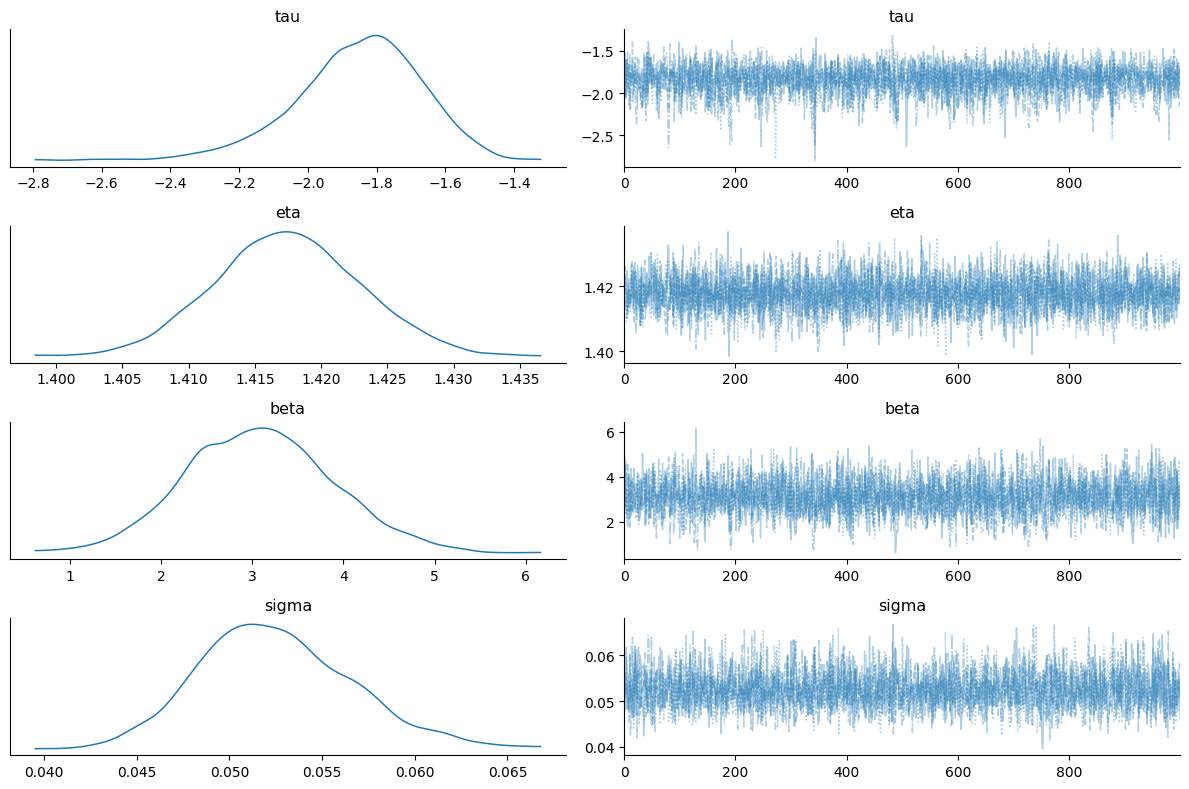

In [37]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

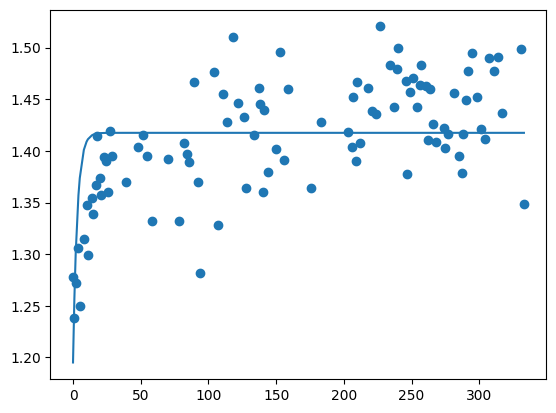

In [38]:
plt.scatter(sessions["Time"], sessions["Efficiency"])
plt.plot(
    sessions["Time"],
    # idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values * (1 - np.exp(-sessions["Time"].values / idata.posterior["beta"].mean().values))
    # (eta - alpha * sessions["Heart Rate"]) * (1 - np.exp(-sessions["Time"].values / beta))

        idata.posterior["eta"].mean().values
 
    * (
        1
        - np.exp(
            idata.posterior["tau"].mean().values
            - sessions["Time"].values / idata.posterior["beta"].mean().values
        )
    ),
)

In [39]:
sessions["Time"] = sessions.index - sessions.index.min()

In [40]:
with pm.Model() as model:
    # Priors for unknown model parameters
    eta = pm.HalfNormal("eta", sigma=1)
    alpha = pm.HalfNormal("alpha", sigma=1)
    beta = pm.HalfNormal("beta", sigma=1)
    tau = pm.Normal("tau", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    # E_0 * (1 - b * np.exp(-day / t))
    # (E_0 - a * hr) * (1 - b * np.exp(-day / t))
    mu = (eta - alpha * sessions["Heart Rate"]) * (1 - np.exp(tau - sessions["Time"].values / beta))

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Efficiency"])

In [41]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

CPU times: total: 10.9 s
Wall time: 3.92 s


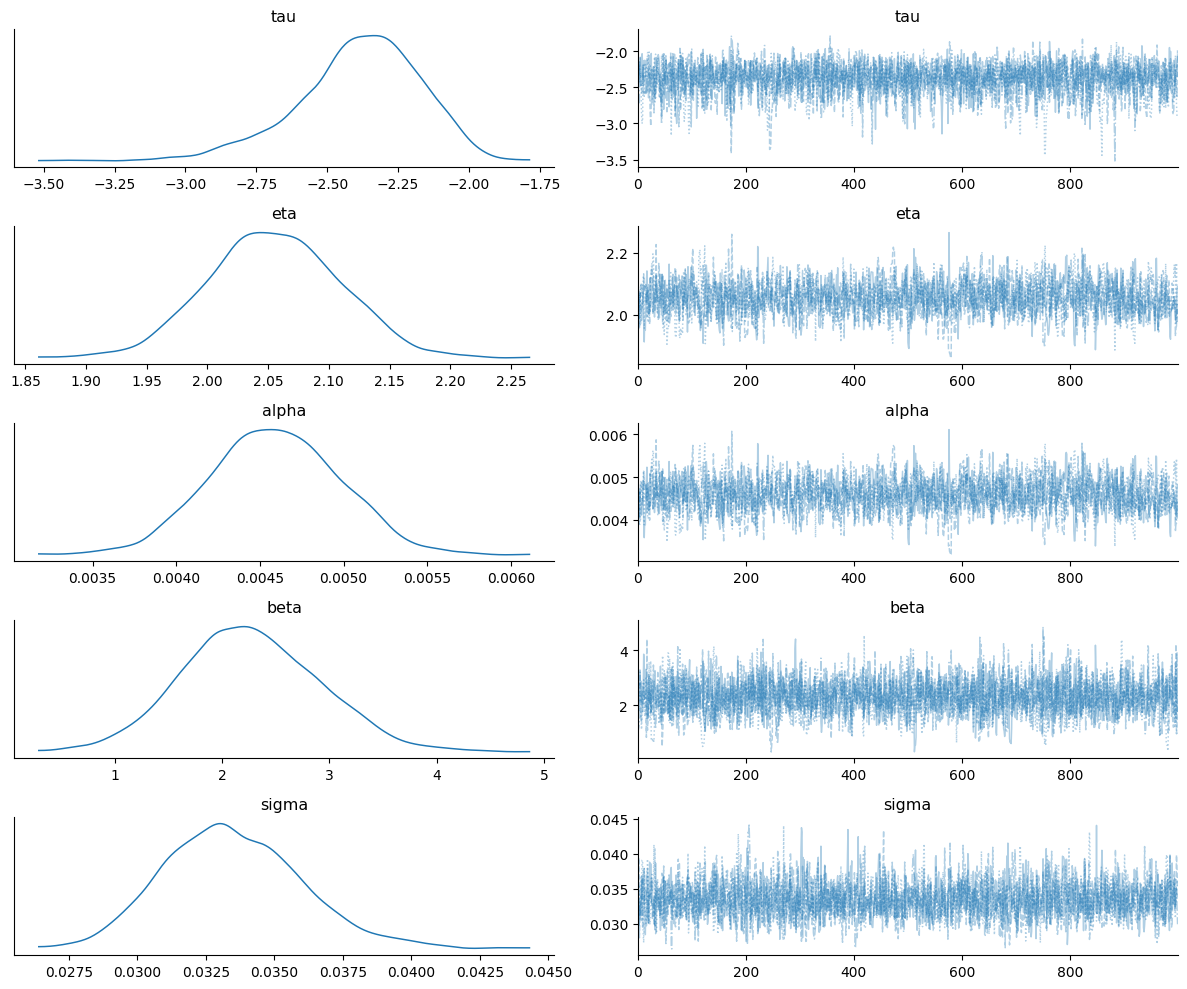

In [42]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

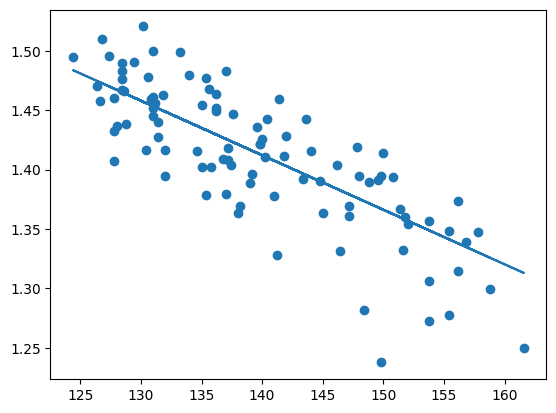

In [43]:
plt.scatter(sessions["Heart Rate"], sessions["Efficiency"])
plt.plot(
    sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values * (1 - np.exp(-sessions["Time"].values / idata.posterior["beta"].mean().values))
    idata.posterior["eta"].mean().values - idata.posterior["alpha"].mean().values * sessions["Heart Rate"]
)

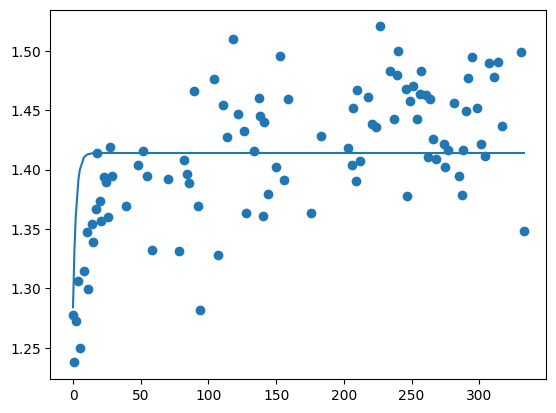

In [44]:
plt.scatter(sessions["Time"], sessions["Efficiency"])
plt.plot(
    sessions["Time"],
    # idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values * (1 - np.exp(-sessions["Time"].values / idata.posterior["beta"].mean().values))
    # (eta - alpha * sessions["Heart Rate"]) * (1 - np.exp(-sessions["Time"].values / beta))
    (
        idata.posterior["eta"].mean().values
        - idata.posterior["alpha"].mean().values * sessions["Heart Rate"].mean()
    )
    * (
        1
        - np.exp(
            idata.posterior["tau"].mean().values
            - sessions["Time"].values / idata.posterior["beta"].mean().values
        )
    ),
)

In [45]:
import xarray as xr

post = idata.posterior
mu_pp = post["alpha"] + post["beta"] * xr.DataArray(sessions["Heart Rate"], dims=["obs_id"])

In [46]:
with model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [Y_obs]


Output()

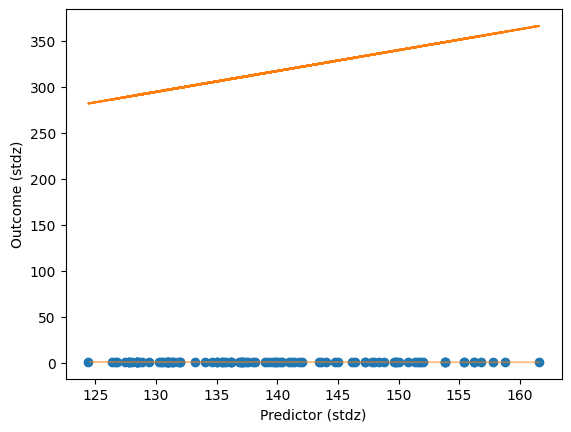

In [47]:
_, ax = plt.subplots()

ax.plot(
    sessions["Heart Rate"], mu_pp.mean(("chain", "draw")), label="Mean outcome", color="C1"
)
ax.scatter(sessions["Heart Rate"], idata.observed_data["Y_obs"])
az.plot_hdi(sessions["Heart Rate"], idata.posterior_predictive["Y_obs"])

ax.set_xlabel("Predictor (stdz)")
ax.set_ylabel("Outcome (stdz)");

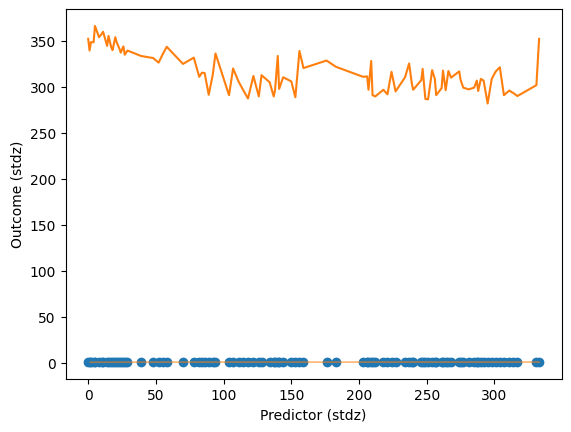

In [48]:
_, ax = plt.subplots()

ax.plot(
    sessions["Time"], mu_pp.mean(("chain", "draw")), label="Mean outcome", color="C1"
)
ax.scatter(sessions["Time"], idata.observed_data["Y_obs"])
az.plot_hdi(sessions["Time"], idata.posterior_predictive["Y_obs"])

ax.set_xlabel("Predictor (stdz)")
ax.set_ylabel("Outcome (stdz)");